# Phase 4 — Détection d'Anomalies

**Input** : `laptop_phase3.csv`  
**Output** : `laptop_phase4.csv` + `anomalies_report.json` + visualisations

**Algorithmes** : Isolation Forest + LOF (Local Outlier Factor)

> Une anomalie de prix = produit dont le prix est **suspect** par rapport à ses caractéristiques (RAM, stockage, plateforme).  
> Prix trop bas → possible arnaque / produit défectueux.  
> Prix trop haut → possible erreur de saisie / produit surévalué.

Étapes :
1. Chargement & préparation
2. Isolation Forest
3. LOF (Local Outlier Factor)
4. Combinaison des deux détecteurs
5. Analyse des anomalies détectées
6. Visualisations
7. Export

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json, os, warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 11

INPUT_PATH   = '../inputs/laptop_phase3.csv'
OUTPUT_DIR   = '../outputs/'
RANDOM_STATE = 42
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('✅ Setup terminé')

✅ Setup terminé


## 1. Chargement & Préparation

In [3]:
df = pd.read_csv(INPUT_PATH)

print(f'Shape : {df.shape}')
print(f'Colonnes : {list(df.columns)}')
print(f'Plateformes : {df["platform"].unique()}')
df.head(3)

Shape : (50, 18)
Colonnes : ['title', 'brand', 'price', 'price_usd', 'currency', 'platform', 'ram_gb', 'storage_gb', 'category', 'search_query', 'url', 'scraped_date', 'price_range', 'cluster_kmeans', 'cluster_kmeans_label', 'cluster_dbscan', 'pca_x', 'pca_y']
Plateformes : <StringArray>
['jumia', 'aliexpress']
Length: 2, dtype: str


,title,brand,price,price_usd,currency,platform,ram_gb,storage_gb,category,search_query,url,scraped_date,price_range,cluster_kmeans,cluster_kmeans_label,cluster_dbscan,pca_x,pca_y
0,"Hp Laptop 15-FC0075k - Ecran FHD 15,6""- Ryzen5...",HP,5799.00,579.90,MAD,jumia,8.0,512.0,electronics,laptop,https://www.jumia.ma/hp-laptop-15-fc0075k-ecra...,2026-05-13,bas_de_gamme,1,bas_de_gamme,-1,-1.776349,0.020174
1,Lenovo ThinkPad X13 Yoga Gen 1 Convertible Lap...,Lenovo,4099.00,409.90,MAD,jumia,16.0,512.0,electronics,laptop,https://www.jumia.ma/lenovo-thinkpad-x13-yoga-...,2026-05-13,bas_de_gamme,1,bas_de_gamme,0,-1.518506,-0.227759
2,2025 MSI Stealth 18 HX AI Gaming Laptop 18 Inc...,MSI,39218.93,3921.89,MAD,aliexpress,64.0,2048.0,electronics,laptop,https://www.aliexpress.com/item/10050116276281...,2026-05-13,haut_de_gamme,2,haut_de_gamme,-1,3.830703,0.758906


In [4]:
# Features pour la détection d'anomalies
# On utilise price + ram_gb + storage_gb (même base que le clustering)
FEATURES = ['price', 'ram_gb', 'storage_gb']

print('=== Diagnostic des features ===')
for col in FEATURES:
    s = df[col]
    print(f'{col:15s}  NaN={s.isna().sum():3d} ({s.isna().mean()*100:.0f}%)  '
          f'min={s.min():.1f}  max={s.max():.1f}  std={s.std():.2f}')

# Deux stratégies :
# - df_full : imputation médiane pour garder tous les produits
# - df_clean : uniquement les lignes avec les 3 features renseignées

df_imputed = df.copy()
for col in ['ram_gb', 'storage_gb']:
    median_val = df[col].median()
    df_imputed[col] = df[col].fillna(median_val)
    print(f'\nImputation {col} : NaN → médiane ({median_val:.0f})')

print(f'\nLignes disponibles (avec imputation) : {len(df_imputed)}')
print(f'Lignes disponibles (sans imputation)  : {df.dropna(subset=FEATURES).shape[0]}')

=== Diagnostic des features ===
price            NaN=  0 (0%)  min=2602.9  max=45362.0  std=9615.94
ram_gb           NaN= 12 (24%)  min=4.0  max=64.0  std=14.30
storage_gb       NaN= 17 (34%)  min=128.0  max=2048.0  std=612.15

Imputation ram_gb : NaN → médiane (20)

Imputation storage_gb : NaN → médiane (1024)

Lignes disponibles (avec imputation) : 50
Lignes disponibles (sans imputation)  : 33


In [5]:
# Normalisation
X = df_imputed[FEATURES].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Features normalisées (mean≈0, std≈1) :')
print(pd.DataFrame(X_scaled, columns=FEATURES).describe().round(3))

Features normalisées (mean≈0, std≈1) :
        price  ram_gb  storage_gb
count  50.000  50.000      50.000
mean    0.000   0.000       0.000
std     1.010   1.010       1.010
min    -1.167  -1.605      -1.895
25%    -0.746  -0.646      -0.068
50%    -0.114  -0.326      -0.068
75%     0.378   0.633      -0.068
max     3.325   3.191       2.021


## 2. Isolation Forest

**Principe** : construit des arbres de décision aléatoires. Un point est anormal s'il est isolé rapidement (chemin court dans l'arbre).  
**`contamination`** : proportion estimée d'anomalies dans le dataset (on teste plusieurs valeurs).

In [6]:
# Choix du taux de contamination
# On teste 5%, 10%, 15% et on observe le nombre de produits flaggés
print('=== Sensibilité au paramètre contamination ===')
print(f'{"contamination":>15}  {"anomalies":>10}  {"% du dataset":>14}')
print('-' * 45)

for cont in [0.05, 0.10, 0.15, 0.20]:
    iso = IsolationForest(contamination=cont, random_state=RANDOM_STATE, n_estimators=200)
    preds = iso.fit_predict(X_scaled)
    n_anom = (preds == -1).sum()
    print(f'{cont:>15.2f}  {n_anom:>10}  {n_anom/len(df)*100:>13.1f}%')

=== Sensibilité au paramètre contamination ===
  contamination   anomalies    % du dataset
---------------------------------------------
           0.05           3            6.0%
           0.10           5           10.0%
           0.15           8           16.0%
           0.20          10           20.0%


In [7]:
# Modèle final : contamination = 0.10 (10% — raisonnable pour un marché e-commerce)
CONTAMINATION = 0.10

iso_final = IsolationForest(
    contamination=CONTAMINATION,
    n_estimators=200,
    random_state=RANDOM_STATE
)

iso_labels  = iso_final.fit_predict(X_scaled)   # -1 = anomalie, 1 = normal
iso_scores  = iso_final.score_samples(X_scaled) # score : plus négatif = plus anormal

df_imputed['iso_label']  = iso_labels
df_imputed['iso_score']  = iso_scores
df_imputed['iso_anomaly'] = (iso_labels == -1).astype(int)

n_iso = df_imputed['iso_anomaly'].sum()
print(f'Isolation Forest (contamination={CONTAMINATION}) :')
print(f'  Anomalies détectées : {n_iso}/{len(df_imputed)} ({n_iso/len(df_imputed)*100:.1f}%)')
print(f'  Normaux             : {len(df_imputed) - n_iso}')

Isolation Forest (contamination=0.1) :
  Anomalies détectées : 5/50 (10.0%)
  Normaux             : 45


## 3. LOF — Local Outlier Factor

**Principe** : compare la densité locale d'un point à celle de ses k plus proches voisins.  
Un point est anormal si sa densité est bien **inférieure** à celle de ses voisins (LOF score >> 1).  
**Avantage** : détecte des anomalies **locales** que Isolation Forest peut manquer.

In [8]:
# Sensibilité au paramètre n_neighbors
print('=== Sensibilité au paramètre n_neighbors (LOF) ===')
print(f'{"n_neighbors":>13}  {"anomalies":>10}  {"% du dataset":>14}')
print('-' * 43)

for k in [5, 10, 15, 20]:
    lof = LocalOutlierFactor(n_neighbors=k, contamination=CONTAMINATION)
    preds = lof.fit_predict(X_scaled)
    n_anom = (preds == -1).sum()
    print(f'{k:>13}  {n_anom:>10}  {n_anom/len(df)*100:>13.1f}%')

=== Sensibilité au paramètre n_neighbors (LOF) ===
  n_neighbors   anomalies    % du dataset
-------------------------------------------
            5           5           10.0%
           10           5           10.0%
           15           5           10.0%
           20           5           10.0%


In [9]:
# Modèle LOF final
N_NEIGHBORS = 10

lof_final = LocalOutlierFactor(
    n_neighbors=N_NEIGHBORS,
    contamination=CONTAMINATION
)

lof_labels  = lof_final.fit_predict(X_scaled)       # -1 = anomalie, 1 = normal
lof_scores  = -lof_final.negative_outlier_factor_   # LOF score (> 1 = anormal)

df_imputed['lof_label']   = lof_labels
df_imputed['lof_score']   = lof_scores
df_imputed['lof_anomaly'] = (lof_labels == -1).astype(int)

n_lof = df_imputed['lof_anomaly'].sum()
print(f'LOF (n_neighbors={N_NEIGHBORS}, contamination={CONTAMINATION}) :')
print(f'  Anomalies détectées : {n_lof}/{len(df_imputed)} ({n_lof/len(df_imputed)*100:.1f}%)')
print(f'  Normaux             : {len(df_imputed) - n_lof}')

LOF (n_neighbors=10, contamination=0.1) :
  Anomalies détectées : 5/50 (10.0%)
  Normaux             : 45


## 4. Combinaison des deux détecteurs

**Stratégie voting** :
- `is_anomaly = 1` si les **deux** algorithmes sont d'accord → **anomalie certaine** (forte confiance)
- `is_anomaly_soft = 1` si **au moins un** algorithme détecte une anomalie → **anomalie possible**

In [10]:
# Voting strict : les deux doivent être d'accord
df_imputed['is_anomaly']      = ((df_imputed['iso_anomaly'] == 1) & (df_imputed['lof_anomaly'] == 1)).astype(int)

# Voting souple : au moins un détecte
df_imputed['is_anomaly_soft'] = ((df_imputed['iso_anomaly'] == 1) | (df_imputed['lof_anomaly'] == 1)).astype(int)

# Score combiné normalisé (0 à 1) : moyenne des scores normalisés
iso_norm = (df_imputed['iso_score'] - df_imputed['iso_score'].min()) / \
           (df_imputed['iso_score'].max() - df_imputed['iso_score'].min())
lof_norm = (df_imputed['lof_score'] - df_imputed['lof_score'].min()) / \
           (df_imputed['lof_score'].max() - df_imputed['lof_score'].min())

# iso_norm inversé (score plus négatif = plus anormal → on inverse)
df_imputed['anomaly_score'] = ((1 - iso_norm) + lof_norm) / 2

n_strict = df_imputed['is_anomaly'].sum()
n_soft   = df_imputed['is_anomaly_soft'].sum()

print('=== RÉSULTATS COMBINÉS ===')
print(f'  Isolation Forest seul  : {df_imputed["iso_anomaly"].sum()} anomalies')
print(f'  LOF seul               : {df_imputed["lof_anomaly"].sum()} anomalies')
print(f'  Accord strict (AND)    : {n_strict} anomalies  ← is_anomaly')
print(f'  Union (OR)             : {n_soft} anomalies  ← is_anomaly_soft')
print()
print('Matrice de concordance :')
print(pd.crosstab(df_imputed['iso_anomaly'], df_imputed['lof_anomaly'],
                  rownames=['Isolation Forest'], colnames=['LOF']))

=== RÉSULTATS COMBINÉS ===
  Isolation Forest seul  : 5 anomalies
  LOF seul               : 5 anomalies
  Accord strict (AND)    : 3 anomalies  ← is_anomaly
  Union (OR)             : 7 anomalies  ← is_anomaly_soft

Matrice de concordance :
LOF                0  1
Isolation Forest       
0                 43  2
1                  2  3


## 5. Analyse des anomalies détectées

In [11]:
df_anomalies = df_imputed[df_imputed['is_anomaly'] == 1].copy()
df_normal    = df_imputed[df_imputed['is_anomaly'] == 0].copy()

print('=== PROFIL DES ANOMALIES (accord strict) ===')
print()
print('Stats prix — anomalies vs normaux :')
comparison = pd.DataFrame({
    'anomalies': df_anomalies['price'].describe(),
    'normaux':   df_normal['price'].describe()
}).round(2)
print(comparison)
print()
print('Répartition par plateforme :')
print(df_anomalies['platform'].value_counts())
print()
print('Répartition par gamme (cluster K-Means) :')
if 'cluster_kmeans_label' in df_imputed.columns:
    print(df_anomalies['cluster_kmeans_label'].value_counts())

=== PROFIL DES ANOMALIES (accord strict) ===

Stats prix — anomalies vs normaux :
       anomalies   normaux
count       3.00     47.00
mean    23357.50  13092.26
std     19980.53   8641.72
min      6349.25   2602.93
25%     12355.23   6707.32
50%     18361.21  12244.42
75%     31861.62  16898.40
max     45362.04  39218.93

Répartition par plateforme :
platform
aliexpress    3
Name: count, dtype: int64

Répartition par gamme (cluster K-Means) :
cluster_kmeans_label
milieu_de_gamme    2
haut_de_gamme      1
Name: count, dtype: int64


In [12]:
print('=== TOP 10 ANOMALIES (score le plus élevé) ===')
cols_display = ['title', 'price', 'ram_gb', 'storage_gb', 'platform', 'anomaly_score']
cols_display = [c for c in cols_display if c in df_imputed.columns]

top_anomalies = df_imputed[df_imputed['is_anomaly'] == 1].nlargest(10, 'anomaly_score')[cols_display]
pd.set_option('display.max_colwidth', 60)
print(top_anomalies.to_string(index=False))

=== TOP 10 ANOMALIES (score le plus élevé) ===
                                                                                                                           title    price  ram_gb  storage_gb   platform  anomaly_score
Lenovo Gaming Laptop LEGION Y9000P 2025 Supreme Edition AI Yuanqi 16-inch 240Hz Ultra9-275HX 32GB+1TB RTX5080 Gaming Notebook PC 45362.04    32.0      1024.0 aliexpress       0.863250
  DR-AZ Gaming Laptop Intel Core i7-13620H 16'' 64GB 2TB computer 1920*1200 5000 mAh Win 11 1920x1200 Fingerprint backlit Laptop  6349.25    64.0      2048.0 aliexpress       0.850470
                  2026 GPD Pocket4 Latest AMD AI 9 HX 370/8840U 64GB 2TB NVMe 8.8 Inch 144Hz 2in1 Laptop Tablet Palm Size MiniPC 18361.21    64.0      2048.0 aliexpress       0.767281


In [13]:
# Qualifier les anomalies : prix trop bas ou trop haut ?
price_median = df_normal['price'].median()

df_imputed['anomaly_type'] = 'normal'
mask_anom = df_imputed['is_anomaly'] == 1
df_imputed.loc[mask_anom & (df_imputed['price'] < price_median), 'anomaly_type'] = 'prix_suspect_bas'
df_imputed.loc[mask_anom & (df_imputed['price'] >= price_median), 'anomaly_type'] = 'prix_suspect_haut'

print(f'Prix médian des normaux : {price_median:.0f} MAD')
print()
print('Types d\'anomalies :')
print(df_imputed['anomaly_type'].value_counts())
print()
print('--- Anomalies prix TROP BAS (< médiane) ---')
bas = df_imputed[df_imputed['anomaly_type'] == 'prix_suspect_bas'][cols_display].sort_values('price')
print(bas.to_string(index=False))
print()
print('--- Anomalies prix TROP HAUT (>= médiane) ---')
haut = df_imputed[df_imputed['anomaly_type'] == 'prix_suspect_haut'][cols_display].sort_values('price', ascending=False)
print(haut.to_string(index=False))

Prix médian des normaux : 12244 MAD

Types d'anomalies :
anomaly_type
normal               47
prix_suspect_haut     2
prix_suspect_bas      1
Name: count, dtype: int64

--- Anomalies prix TROP BAS (< médiane) ---
                                                                                                                         title   price  ram_gb  storage_gb   platform  anomaly_score
DR-AZ Gaming Laptop Intel Core i7-13620H 16'' 64GB 2TB computer 1920*1200 5000 mAh Win 11 1920x1200 Fingerprint backlit Laptop 6349.25    64.0      2048.0 aliexpress        0.85047

--- Anomalies prix TROP HAUT (>= médiane) ---
                                                                                                                           title    price  ram_gb  storage_gb   platform  anomaly_score
Lenovo Gaming Laptop LEGION Y9000P 2025 Supreme Edition AI Yuanqi 16-inch 240Hz Ultra9-275HX 32GB+1TB RTX5080 Gaming Notebook PC 45362.04    32.0      1024.0 aliexpress       0.863250
          

## 6. Visualisations

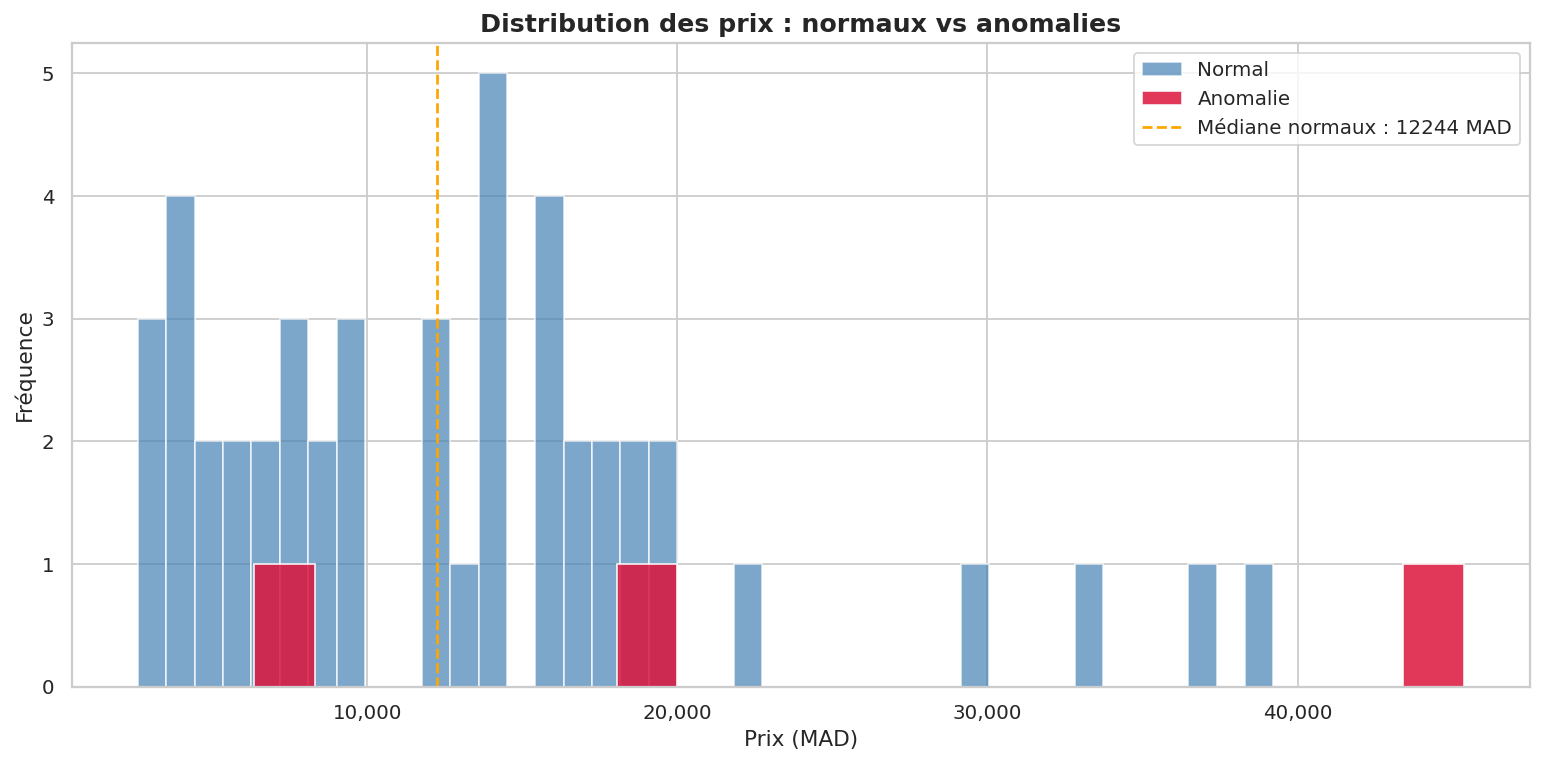

✅ phase4_distribution_anomalies.png


In [14]:
# 6.1 Distribution des prix : normaux vs anomalies
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(df_normal['price'], bins=40, alpha=0.7, color='steelblue', label='Normal', edgecolor='white')
ax.hist(df_anomalies['price'], bins=20, alpha=0.85, color='crimson', label='Anomalie', edgecolor='white')
ax.axvline(price_median, color='orange', linestyle='--', linewidth=1.5, label=f'Médiane normaux : {price_median:.0f} MAD')
ax.set_title('Distribution des prix : normaux vs anomalies', fontsize=14, fontweight='bold')
ax.set_xlabel('Prix (MAD)'); ax.set_ylabel('Fréquence')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase4_distribution_anomalies.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ phase4_distribution_anomalies.png')

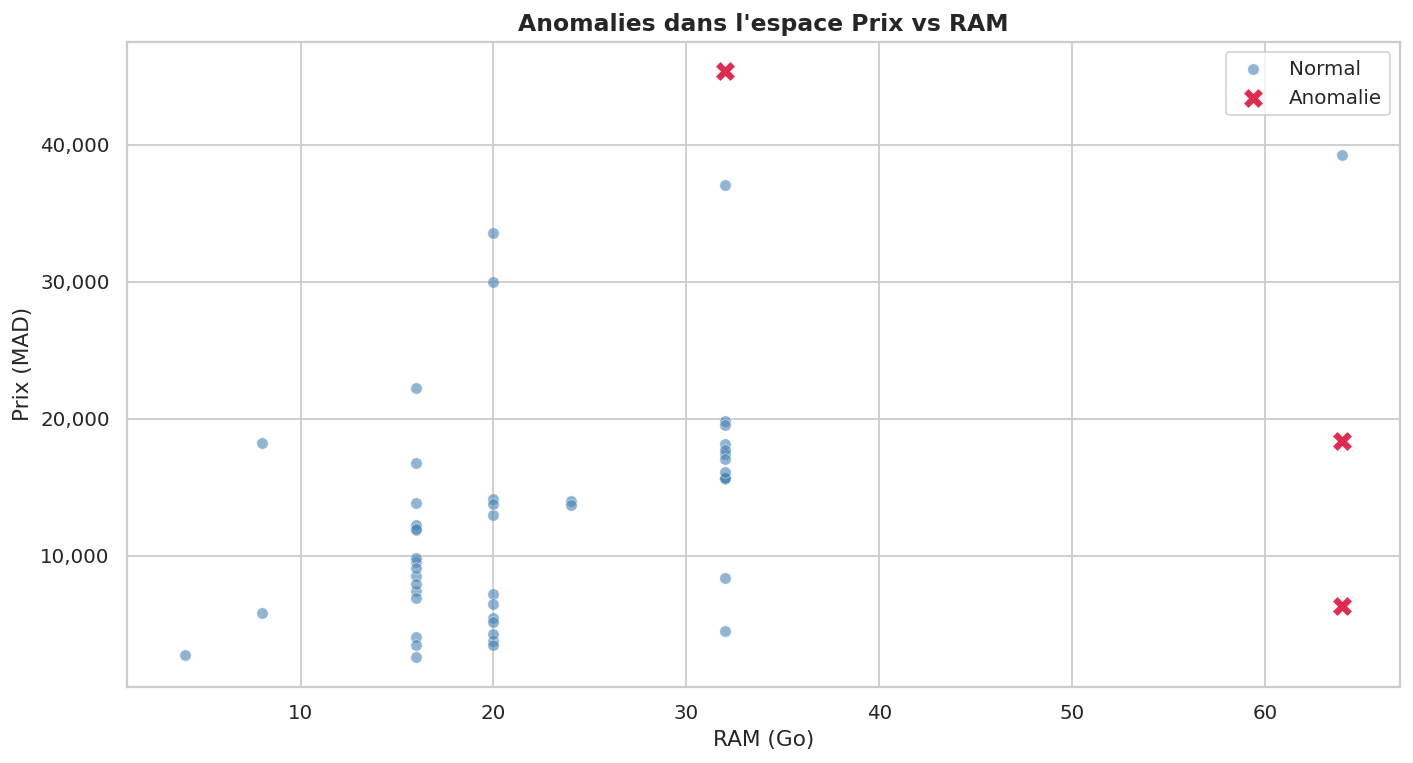

✅ phase4_scatter_ram_anomalies.png


In [15]:
# 6.2 Scatter price vs ram_gb coloré par anomalie
df_plot = df_imputed.dropna(subset=['ram_gb'])
colors  = df_plot['is_anomaly'].map({0: 'steelblue', 1: 'crimson'})

fig, ax = plt.subplots(figsize=(11, 6))
for label, color, marker in [(0, 'steelblue', 'o'), (1, 'crimson', 'X')]:
    mask = df_plot['is_anomaly'] == label
    ax.scatter(df_plot.loc[mask, 'ram_gb'], df_plot.loc[mask, 'price'],
               c=color, label='Normal' if label == 0 else 'Anomalie',
               alpha=0.6 if label == 0 else 0.9,
               s=40 if label == 0 else 120,
               marker=marker, edgecolors='white', linewidths=0.4)
ax.set_title('Anomalies dans l\'espace Prix vs RAM', fontsize=13, fontweight='bold')
ax.set_xlabel('RAM (Go)'); ax.set_ylabel('Prix (MAD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase4_scatter_ram_anomalies.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ phase4_scatter_ram_anomalies.png')

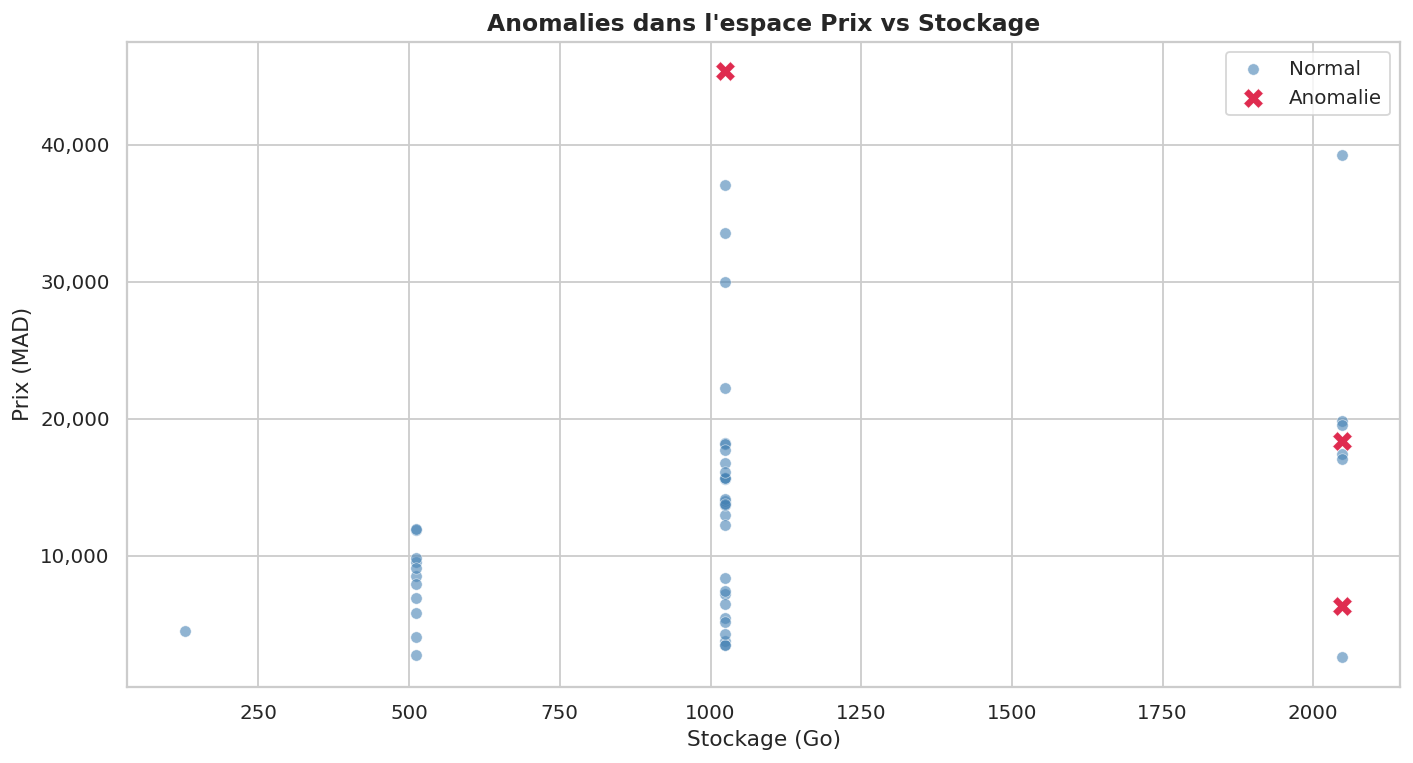

✅ phase4_scatter_storage_anomalies.png


In [16]:
# 6.3 Scatter price vs storage_gb coloré par anomalie
df_plot2 = df_imputed.dropna(subset=['storage_gb'])

fig, ax = plt.subplots(figsize=(11, 6))
for label, color, marker in [(0, 'steelblue', 'o'), (1, 'crimson', 'X')]:
    mask = df_plot2['is_anomaly'] == label
    ax.scatter(df_plot2.loc[mask, 'storage_gb'], df_plot2.loc[mask, 'price'],
               c=color, label='Normal' if label == 0 else 'Anomalie',
               alpha=0.6 if label == 0 else 0.9,
               s=40 if label == 0 else 120,
               marker=marker, edgecolors='white', linewidths=0.4)
ax.set_title('Anomalies dans l\'espace Prix vs Stockage', fontsize=13, fontweight='bold')
ax.set_xlabel('Stockage (Go)'); ax.set_ylabel('Prix (MAD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase4_scatter_storage_anomalies.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ phase4_scatter_storage_anomalies.png')

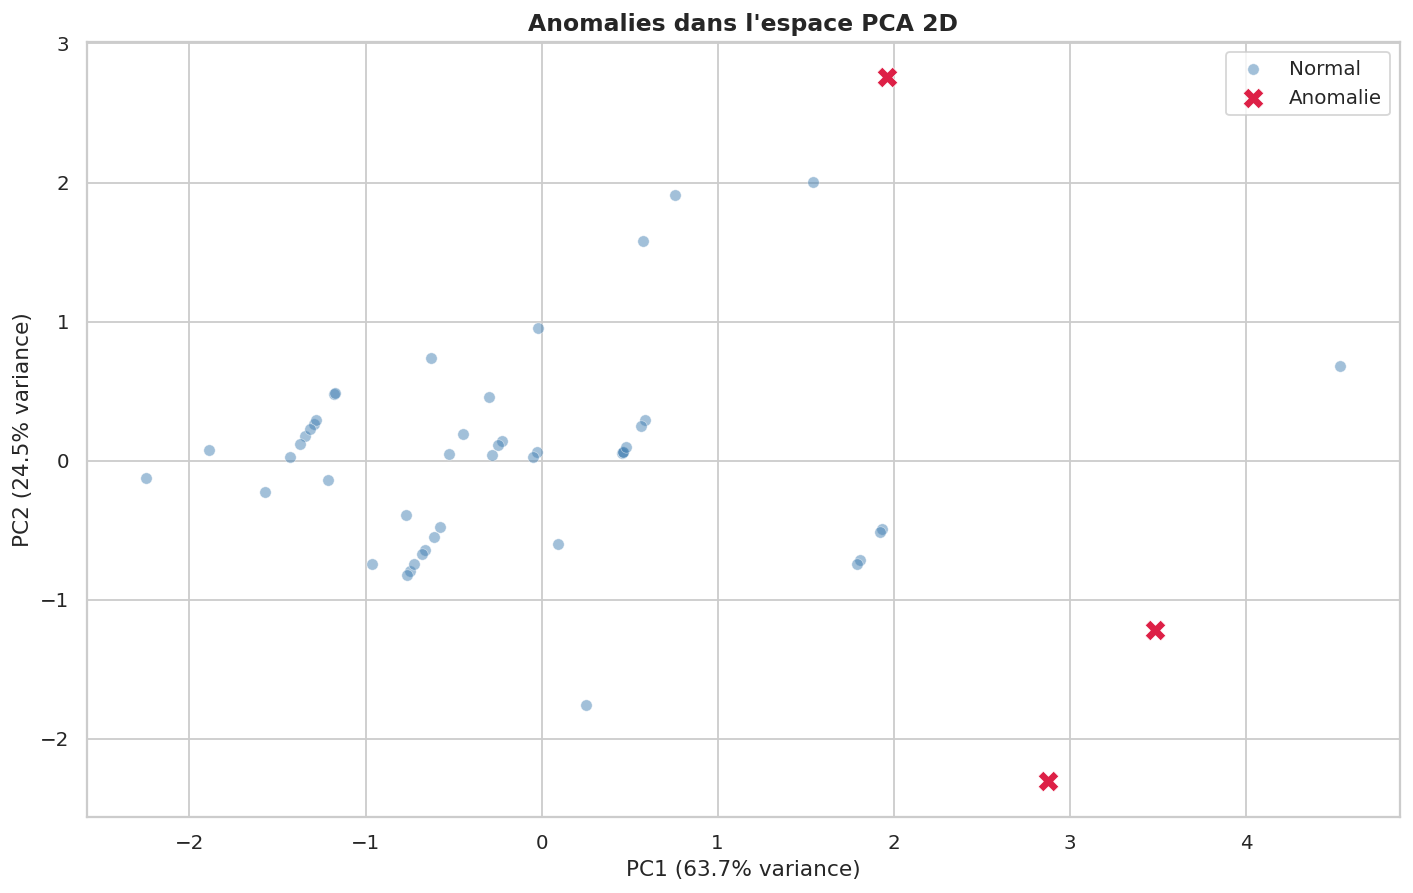

✅ phase4_pca_anomalies.png  (variance expliquée : 88.2%)


In [17]:
# 6.4 PCA 2D pour visualiser les anomalies
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

df_imputed['pca_x'] = X_pca[:, 0]
df_imputed['pca_y'] = X_pca[:, 1]

fig, ax = plt.subplots(figsize=(11, 7))
for label, color, marker, size, alpha in [(0, 'steelblue', 'o', 40, 0.5), (1, 'crimson', 'X', 130, 0.95)]:
    mask = df_imputed['is_anomaly'] == label
    ax.scatter(df_imputed.loc[mask, 'pca_x'], df_imputed.loc[mask, 'pca_y'],
               c=color, label='Normal' if label == 0 else 'Anomalie',
               s=size, alpha=alpha, marker=marker, edgecolors='white', linewidths=0.4)

var = pca.explained_variance_ratio_
ax.set_title('Anomalies dans l\'espace PCA 2D', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({var[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({var[1]*100:.1f}% variance)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase4_pca_anomalies.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ phase4_pca_anomalies.png  (variance expliquée : {sum(var)*100:.1f}%)')

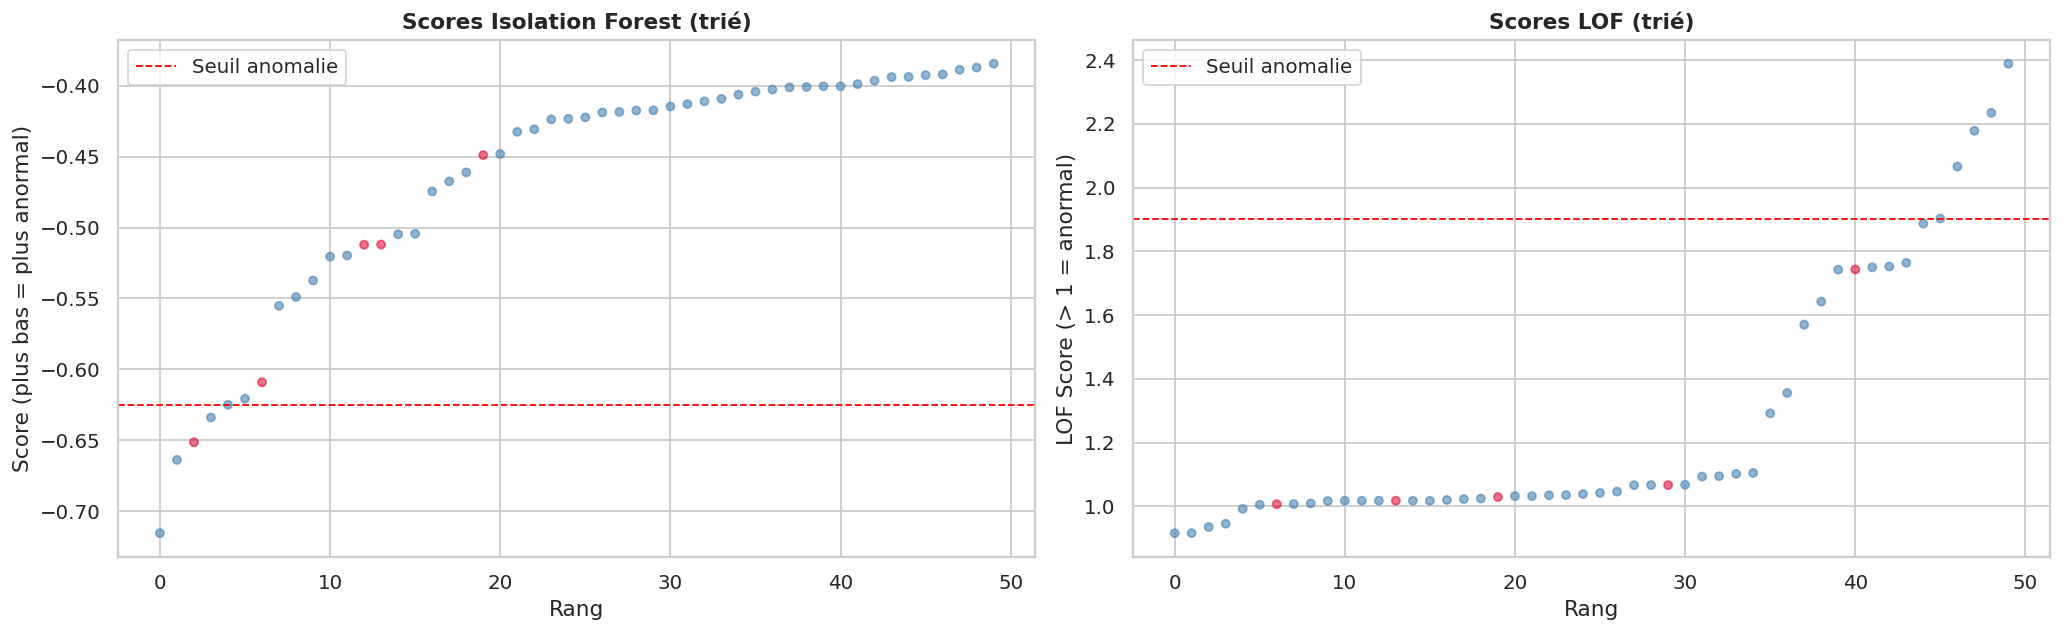

✅ phase4_scores_iso_lof.png


In [18]:
# 6.5 Score d'anomalie combiné
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Isolation Forest scores
colors_iso = df_imputed['iso_anomaly'].map({1: 'crimson', 0: 'steelblue'})
axes[0].scatter(range(len(df_imputed)), df_imputed['iso_score'].sort_values(),
                c=colors_iso.values, alpha=0.6, s=20)
axes[0].set_title('Scores Isolation Forest (trié)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Rang'); axes[0].set_ylabel('Score (plus bas = plus anormal)')
axes[0].axhline(df_imputed[df_imputed['iso_anomaly'] == 1]['iso_score'].max(),
                color='red', linestyle='--', linewidth=1, label='Seuil anomalie')
axes[0].legend()

# LOF scores
colors_lof = df_imputed['lof_anomaly'].map({1: 'crimson', 0: 'steelblue'})
axes[1].scatter(range(len(df_imputed)), df_imputed['lof_score'].sort_values(),
                c=colors_lof.values, alpha=0.6, s=20)
axes[1].set_title('Scores LOF (trié)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Rang'); axes[1].set_ylabel('LOF Score (> 1 = anormal)')
axes[1].axhline(df_imputed[df_imputed['lof_anomaly'] == 1]['lof_score'].min(),
                color='red', linestyle='--', linewidth=1, label='Seuil anomalie')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase4_scores_iso_lof.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ phase4_scores_iso_lof.png')

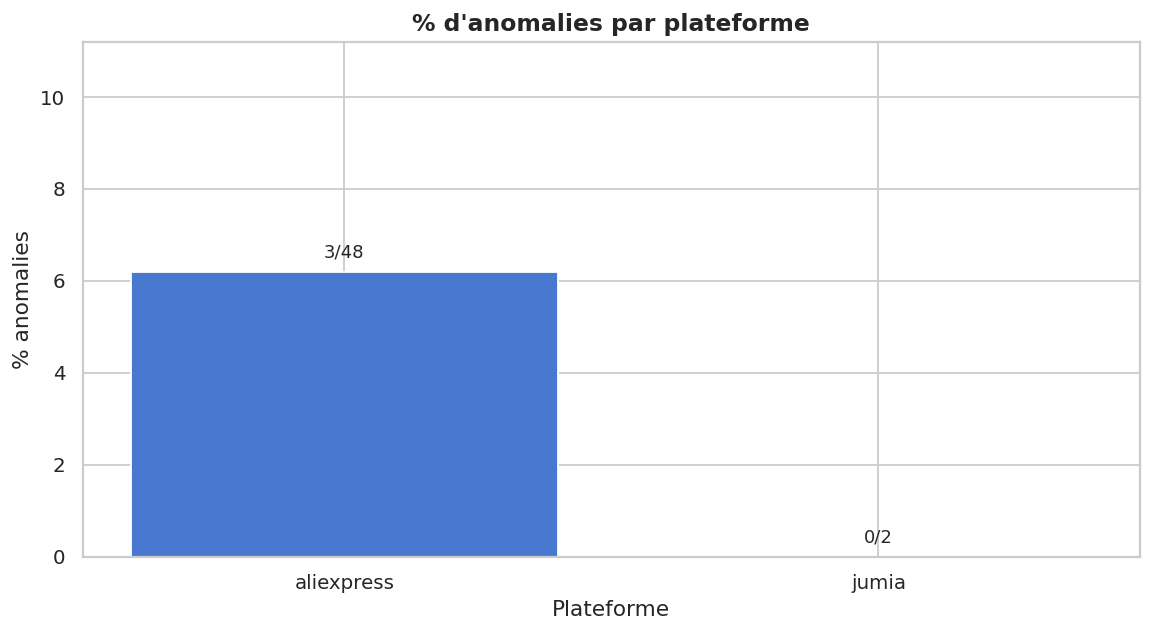

✅ phase4_anomalies_par_platform.png


In [19]:
# 6.6 Anomalies par plateforme
platform_anom = df_imputed.groupby('platform')['is_anomaly'].agg(['sum', 'count'])
platform_anom['pct'] = (platform_anom['sum'] / platform_anom['count'] * 100).round(1)
platform_anom.columns = ['anomalies', 'total', '% anomalies']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(platform_anom.index, platform_anom['% anomalies'],
              color=sns.color_palette('muted', len(platform_anom)), edgecolor='white')
for bar, (_, row) in zip(bars, platform_anom.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{row["anomalies"]:.0f}/{row["total"]:.0f}', ha='center', fontsize=10)
ax.set_title('% d\'anomalies par plateforme', fontsize=13, fontweight='bold')
ax.set_xlabel('Plateforme'); ax.set_ylabel('% anomalies')
ax.set_ylim(0, platform_anom['% anomalies'].max() + 5)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase4_anomalies_par_platform.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ phase4_anomalies_par_platform.png')

## 7. Export

In [20]:
# Remettre les colonnes d'anomalie dans le df original
df['iso_score']       = df_imputed['iso_score'].values
df['lof_score']       = df_imputed['lof_score'].values
df['anomaly_score']   = df_imputed['anomaly_score'].values
df['is_anomaly']      = df_imputed['is_anomaly'].values
df['is_anomaly_soft'] = df_imputed['is_anomaly_soft'].values
df['anomaly_type']    = df_imputed['anomaly_type'].values
df['pca_x']           = df_imputed['pca_x'].values
df['pca_y']           = df_imputed['pca_y'].values

df.to_csv('../inputs/laptop_phase4.csv', index=False, encoding='utf-8')
print(f'✅ laptop_phase4.csv  ({df.shape})')
print(f'   Colonnes ajoutées : iso_score, lof_score, anomaly_score, is_anomaly, is_anomaly_soft, anomaly_type, pca_x, pca_y')

✅ laptop_phase4.csv  ((50, 24))
   Colonnes ajoutées : iso_score, lof_score, anomaly_score, is_anomaly, is_anomaly_soft, anomaly_type, pca_x, pca_y


In [21]:
# JSON rapport pour Django
anomalies_list = df[df['is_anomaly'] == 1][['title', 'price', 'platform', 'anomaly_score', 'anomaly_type']]\
    .sort_values('anomaly_score', ascending=False)\
    .to_dict(orient='records')

report = {
    'config': {
        'features':      FEATURES,
        'contamination': CONTAMINATION,
        'iso_n_estimators': 200,
        'lof_n_neighbors':  N_NEIGHBORS,
        'voting': 'strict (AND)'
    },
    'summary': {
        'total_products':          len(df),
        'iso_anomalies':           int(df_imputed['iso_anomaly'].sum()),
        'lof_anomalies':           int(df_imputed['lof_anomaly'].sum()),
        'strict_anomalies':        int(df['is_anomaly'].sum()),
        'soft_anomalies':          int(df['is_anomaly_soft'].sum()),
        'anomaly_rate_pct':        round(df['is_anomaly'].mean() * 100, 2),
        'prix_suspect_bas':        int((df['anomaly_type'] == 'prix_suspect_bas').sum()),
        'prix_suspect_haut':       int((df['anomaly_type'] == 'prix_suspect_haut').sum()),
        'price_median_normal':     round(float(price_median), 2)
    },
    'by_platform': platform_anom.reset_index().to_dict(orient='records'),
    'anomalies':   anomalies_list
}

json_path = os.path.join(OUTPUT_DIR, 'anomalies_report.json')
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(report, f, ensure_ascii=False, indent=2)

print('✅ anomalies_report.json')
print(json.dumps(report['summary'], indent=2))

✅ anomalies_report.json
{
  "total_products": 50,
  "iso_anomalies": 5,
  "lof_anomalies": 5,
  "strict_anomalies": 3,
  "soft_anomalies": 7,
  "anomaly_rate_pct": 6.0,
  "prix_suspect_bas": 1,
  "prix_suspect_haut": 2,
  "price_median_normal": 12244.42
}


In [22]:
print('=' * 62)
print('         RÉSUMÉ — PHASE 4 TERMINÉE')
print('=' * 62)
print(f'  Features utilisées    : {FEATURES}')
print(f'  Produits analysés     : {len(df)}')
print(f'  Isolation Forest      : {int(df_imputed["iso_anomaly"].sum())} anomalies')
print(f'  LOF                   : {int(df_imputed["lof_anomaly"].sum())} anomalies')
print(f'  Accord strict (AND)   : {int(df["is_anomaly"].sum())} anomalies ({df["is_anomaly"].mean()*100:.1f}%)')
print(f'  Prix suspects BAS     : {int((df["anomaly_type"] == "prix_suspect_bas").sum())}')
print(f'  Prix suspects HAUT    : {int((df["anomaly_type"] == "prix_suspect_haut").sum())}')
print('=' * 62)
print('  Fichiers produits :')
print('    📄 laptop_phase4.csv                (+ is_anomaly + anomaly_type + scores)')
print('    📊 anomalies_report.json')
print('    🖼  phase4_distribution_anomalies.png')
print('    🖼  phase4_scatter_ram_anomalies.png')
print('    🖼  phase4_scatter_storage_anomalies.png')
print('    🖼  phase4_pca_anomalies.png')
print('    🖼  phase4_scores_iso_lof.png')
print('    🖼  phase4_anomalies_par_platform.png')
print('=' * 62)
print('  ➡  Prochain input pour Phase 5 : laptop_phase4.csv')

         RÉSUMÉ — PHASE 4 TERMINÉE
  Features utilisées    : ['price', 'ram_gb', 'storage_gb']
  Produits analysés     : 50
  Isolation Forest      : 5 anomalies
  LOF                   : 5 anomalies
  Accord strict (AND)   : 3 anomalies (6.0%)
  Prix suspects BAS     : 1
  Prix suspects HAUT    : 2
  Fichiers produits :
    📄 laptop_phase4.csv                (+ is_anomaly + anomaly_type + scores)
    📊 anomalies_report.json
    🖼  phase4_distribution_anomalies.png
    🖼  phase4_scatter_ram_anomalies.png
    🖼  phase4_scatter_storage_anomalies.png
    🖼  phase4_pca_anomalies.png
    🖼  phase4_scores_iso_lof.png
    🖼  phase4_anomalies_par_platform.png
  ➡  Prochain input pour Phase 5 : laptop_phase4.csv
